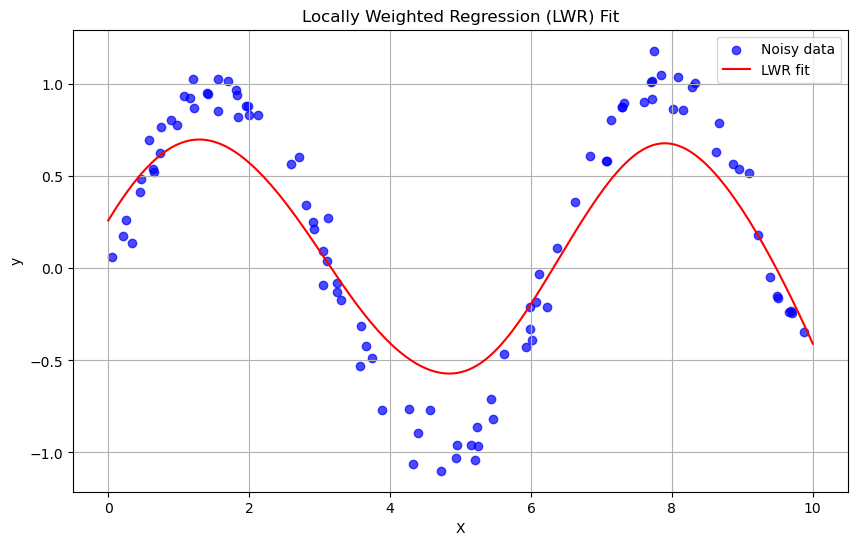

In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
 
# Step 1: Generate dataset (sinusoidal with noise) 
np.random.seed(42)  # For reproducibility 
X = np.sort(np.random.rand(100, 1) * 10, axis=0)  # Random x values between 0 and 
10 
y = np.sin(X) + 0.1 * np.random.randn(100, 1)  # y = sin(x) with noise 
 
# Step 2: Implement Locally Weighted Regression (LWR) 
def locally_weighted_regression(X_train, y_train, x_query, tau=1.0): 
    m, n = X_train.shape 
    weights = np.zeros((m, m)) 
     
    # Create the weight matrix 
    for i in range(m): 
        diff = x_query - X_train[i] 
        weights[i, i] = np.exp(-np.sum(diff ** 2) / (2 * tau ** 2))  # Gaussian kernel 
     
    # Compute theta using the weighted least squares method 
    X_transpose = np.hstack([np.ones((m, 1)), X_train])  # Add bias term (1) 
    X_transpose_T = X_transpose.T 
    theta = np.linalg.inv(X_transpose_T @ (weights @ X_transpose)) @ (X_transpose_T @ (weights @ y_train)) 
     
    return theta[0] + theta[1] * x_query  # Return the prediction for the query point 
 
# Step 3: Fit LWR for each point in the range and plot the results 
tau = 1.0  # Bandwidth parameter 
X_query = np.linspace(0, 10, 200).reshape(-1, 1)  # Query points for prediction 
y_pred = np.zeros_like(X_query) 
 
for i, x in enumerate(X_query): 
    y_pred[i] = locally_weighted_regression(X, y, x, tau) 
 
# Step 4: Visualize the results 
plt.figure(figsize=(10, 6)) 
plt.scatter(X, y, color='blue', label='Noisy data', alpha=0.7) 
plt.plot(X_query, y_pred, color='red', label='LWR fit') 
plt.title("Locally Weighted Regression (LWR) Fit") 
plt.xlabel('X') 
plt.ylabel('y') 
plt.legend() 
plt.grid(True) 
plt.show() 

C:\Users\Prateek\AppData\Local\Temp\ipykernel_14900\2661738957.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  weights[j,j] = np.exp(diff*diff.T/(-2.0*k**2))
C:\Users\Prateek\AppData\Local\Temp\ipykernel_14900\2661738957.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ypred[i] = xmat[i]*localWeight(xmat[i],xmat,ymat,k)


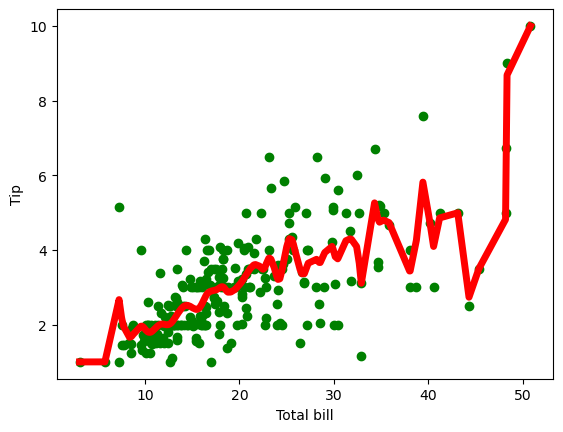

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def kernel(point, xmat, k):
    m,n = np.shape(xmat)
    weights = np.mat(np.eye((m)))
    for j in range(m):
        diff = point - X[j]
        weights[j,j] = np.exp(diff*diff.T/(-2.0*k**2))
    return weights

def localWeight(point, xmat, ymat, k):
    wei = kernel(point,xmat,k)
    W = (X.T*(wei*X)).I*(X.T*(wei*ymat.T))
    return W
     
def localWeightRegression(xmat, ymat, k):
    m,n = np.shape(xmat)
    ypred = np.zeros(m)
    for i in range(m):
        ypred[i] = xmat[i]*localWeight(xmat[i],xmat,ymat,k)
    return ypred
       
# load data points
data = pd.read_csv(r'F:\COLLEGE\NOTES\6TH SEM\ML Lab\Datasets\10-dataset.csv')
bill = np.array(data.total_bill)
tip = np.array(data.tip)
 
#preparing and add 1 in bill
mbill = np.mat(bill)
mtip = np.mat(tip)

m= np.shape(mbill)[1]
one = np.mat(np.ones(m))
X = np.hstack((one.T,mbill.T))

#set k here
ypred = localWeightRegression(X,mtip,0.5)
SortIndex = X[:,1].argsort(0)
xsort = X[SortIndex][:,0]

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.scatter(bill,tip, color='green')
ax.plot(xsort[:,1],ypred[SortIndex], color = 'red', linewidth=5)
plt.xlabel('Total bill')
plt.ylabel('Tip')
plt.show()

C:\Users\Prateek\AppData\Local\Temp\ipykernel_14900\347699627.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ypred[i] = xmat[i] @ localWeight(xmat[i], xmat, ymat, k)


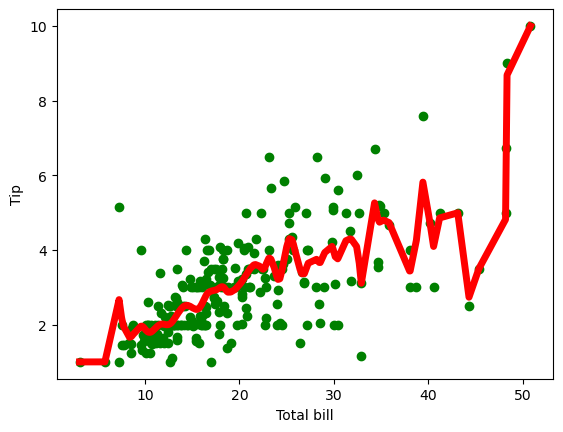

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def kernel(point, xmat, k):
    m, n = xmat.shape
    weights = np.eye(m)
    for j in range(m):
        diff = point - xmat[j]
        weights[j, j] = np.exp((diff @ diff.T) / (-2.0 * k**2))
    return weights

def localWeight(point, xmat, ymat, k):
    wei = kernel(point, xmat, k)
    XTWX = xmat.T @ wei @ xmat
    XTWy = xmat.T @ wei @ ymat
    W = np.linalg.inv(XTWX) @ XTWy
    return W

def localWeightRegression(xmat, ymat, k):
    m, n = xmat.shape
    ypred = np.zeros(m)
    for i in range(m):
        ypred[i] = xmat[i] @ localWeight(xmat[i], xmat, ymat, k)
    return ypred

# load data
data = pd.read_csv(r'F:\COLLEGE\NOTES\6TH SEM\ML Lab\Datasets\10-dataset.csv')

bill = data.total_bill.values
tip = data.tip.values

# preparing X
m = len(bill)
one = np.ones(m)
X = np.column_stack((one, bill))   # shape (m,2)
ymat = tip.reshape(-1, 1)          # column vector

# set k
ypred = localWeightRegression(X, ymat, 0.5)

# sorting for plotting
SortIndex = X[:, 1].argsort()
xsort = X[SortIndex]

fig = plt.figure()
ax = fig.add_subplot(1,1,1)

ax.scatter(bill, tip, color='green')
ax.plot(xsort[:,1], ypred[SortIndex], color='red', linewidth=5)

plt.xlabel('Total bill')
plt.ylabel('Tip')
plt.show()